In [2]:
import bbknn
import lamindb as ln
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scib
import scvi
import warnings
import anndata as ad
import harmonypy as hm

# This looks for any warning containing this specific text
warnings.filterwarnings("ignore", message=".*encoding metadata.*")
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.filterwarnings(
    "ignore", message=".*The default of observed=False is deprecated.*"
)

In [3]:
# load in datasets for integration

adata1 = sc.read_h5ad(
    "/rds/general/user/ztb25/home/PBMC_datasets/1/PBMC1_clustering.h5ad"
)
# adata4 = sc.read_h5ad(
#     "/rds/general/user/ztb25/home/PBMC_datasets/4/PBMC2_clustering.h5ad"
# )
adata5 = sc.read_h5ad(
    "/rds/general/user/ztb25/home/PBMC_datasets/5/PBMC5_clustering.h5ad"
)
# adata6 = sc.read_h5ad(
#     "/rds/general/user/ztb25/home/PBMC_datasets/6/PBMC4_clustering.h5ad"
# )

# for now only using 2 datasets to confirm the integration process works and save memory

In [4]:
adata1

AnnData object with n_obs × n_vars = 54057 × 19936
    obs: 'gsm_id', 'diagnosis', 'age', 'gender', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet', 'leiden_res0_25', 'leiden_res0_5', 'leiden_res1', 'leiden_res2', 'manual_celltype_annotation_0_25', 'celltypist_cell_label_coarse', 'celltypist_conf_score_coarse', 'celltypist_cell_label_fine', 'celltypist_conf_score_fine'
    var: 'gene_ids', 'feature_types', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'celltypist_cell_label_coarse_colors', 'celltypist_cell_label_fine_colors', 'dendrogram_leiden_res0_25', 'gend

In [5]:
adata5

AnnData object with n_obs × n_vars = 78876 × 20053
    obs: 'orig.ident', 'simpl_ID', 'soup_ID_simpl', 'Donor', 'sample', 'diagnosis', 'gender', 'age', 'nCount_RNA', 'nFeature_RNA', 'nCount_HTO', 'nFeature_HTO', 'nCount_SCT', 'nFeature_SCT', 'percent.mt', 'predicted.celltype.l1', 'predicted.celltype.l1.score', 'predicted.celltype.l2', 'predicted.celltype.l2.score', 'scibet', 'final_anno', 'final_broad', 'Simplified_Idents', 'ASG_Score1', 'VDJ_barcode', 'CTgene', 'CTnt', 'CTaa', 'CTstrict', 'Frequency', 'cloneType', 'Monocle3_clusters', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'leiden_res0_25', 'leiden_res0_5', 'leiden_res1', 'leiden_res2', 'manual_celltype_annotation_0_25', 'manual_celltype_annotation_1', 'celltypist_cell_label_coarse', 'celltypist_conf_score_coarse', 'celltypist_cell_label_fine', 'celltypist_conf_score_fine'
    var: 'gene_ids', 'feat

In [6]:
# fix sample column of adata5 (from CTRL1, PD1 etc. -> 1-24)

adata5.obs["sample"] = (
    adata5.obs["sample"].cat.codes + 1
)

adata5.obs

,orig.ident,simpl_ID,soup_ID_simpl,Donor,sample,diagnosis,gender,age,nCount_RNA,nFeature_RNA,...,leiden_res0_25,leiden_res0_5,leiden_res1,leiden_res2,manual_celltype_annotation_0_25,manual_celltype_annotation_1,celltypist_cell_label_coarse,celltypist_conf_score_coarse,celltypist_cell_label_fine,celltypist_conf_score_fine
DM029P_PD_MX1_AAACCTGAGAGGACGG-1,MX1,MX1_AAACCTGAGAGGACGG-1,E,DM029P,13,PD,M,65,7477,2743,...,2,0,2,3,NK,Naive CD8+ T cells,Monocytes,0.999871,Classical monocytes,0.999817
DM029P_PD_MX1_AAACCTGAGCTAACAA-1,MX1,MX1_AAACCTGAGCTAACAA-1,E,DM029P,13,PD,M,65,4667,1950,...,1,3,3,17,CD14+ MONO,CD56dim NK cells,ILC,0.999961,CD16+ NK cells,0.997699
DM009C_CTRL_MX1_AAACCTGAGCTGTTCA-1,MX1,MX1_AAACCTGAGCTGTTCA-1,A,DM009C,10,CTRL,M,52,7322,2084,...,0,1,1,2,Naive T cells,Naive/Tcm CD4+ T cells,T cells,0.999996,Tem/Effector helper T cells,0.993148
DM006C_CTRL_MX1_AAACCTGCAATCAGAA-1,MX1,MX1_AAACCTGCAATCAGAA-1,B,DM006C,5,CTRL,F,72,7842,2742,...,2,0,2,3,NK,Naive CD8+ T cells,Monocytes,0.999963,Classical monocytes,0.999883
DM029P_PD_MX1_AAACCTGCATCCGTGG-1,MX1,MX1_AAACCTGCATCCGTGG-1,E,DM029P,13,PD,M,65,5301,2226,...,1,3,3,1,CD14+ MONO,CD56dim NK cells,ILC,0.999948,CD16+ NK cells,0.999213
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Prat_2020_10_CTRL_MX6_TTTGTCATCGGATGTT-1,MX6,MX6_TTTGTCATCGGATGTT-1,A,Prat_2020_10,1,CTRL,F,82,2450,1204,...,2,0,2,3,NK,Naive CD8+ T cells,Monocytes,0.948640,Classical monocytes,0.970597
Prat_2020_10_CTRL_MX6_TTTGTCATCGTAGGTT-1,MX6,MX6_TTTGTCATCGTAGGTT-1,A,Prat_2020_10,1,CTRL,F,82,6360,2307,...,3,5,5,7,Effector CD8+ T cells,CD8+ Temra,Monocytes,0.999993,Non-classical monocytes,0.999984
Prat_2020_10_CTRL_MX6_TTTGTCATCTCGCATC-1,MX6,MX6_TTTGTCATCTCGCATC-1,A,Prat_2020_10,1,CTRL,F,82,7077,2370,...,3,5,5,7,Effector CD8+ T cells,CD8+ Temra,Monocytes,0.999187,Non-classical monocytes,0.993835
UTMAB_49_PD_MX6_TTTGTCATCTCGTTTA-1,MX6,MX6_TTTGTCATCTCGTTTA-1,C,UTMAB_49,18,PD,M,71,3914,1315,...,0,2,0,0,Naive T cells,CD14+ MONO,T cells,1.000000,Tcm/Naive helper T cells,0.999990


In [7]:
# concatenate the datasets

adata_outer = ad.concat(
     {"1": adata1, "5": adata5}, ## add other two datasets here 
    label="dataset",
    index_unique="-",
    join="outer",
    merge="unique", # check which is most appropriate 
)

adata_inner = ad.concat(
     {"1": adata1, "5": adata5},
    label="dataset",
    index_unique="-",
    join="inner",
    merge="unique",
)

# adata_outer keeps the union of genes across datasets (missings filled with 0s), adata_inner keeps the intersection of genes across datasets (only genes present in both datasets are kept)

adata = adata_outer.copy() # for now, will use adata_outer, but will need to change this for scvi and scANVI which require inner join

In [8]:
adata

AnnData object with n_obs × n_vars = 132933 × 22220
    obs: 'gsm_id', 'diagnosis', 'age', 'gender', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet', 'leiden_res0_25', 'leiden_res0_5', 'leiden_res1', 'leiden_res2', 'manual_celltype_annotation_0_25', 'celltypist_cell_label_coarse', 'celltypist_conf_score_coarse', 'celltypist_cell_label_fine', 'celltypist_conf_score_fine', 'orig.ident', 'simpl_ID', 'soup_ID_simpl', 'Donor', 'nCount_RNA', 'nFeature_RNA', 'nCount_HTO', 'nFeature_HTO', 'nCount_SCT', 'nFeature_SCT', 'percent.mt', 'predicted.celltype.l1', 'predicted.celltype.l1.score', 'predicted.celltype.l2', 'predicted.celltype.l2.score', 'scibet', 'final_anno', 'final_broad', 'Simplified_Idents', 'ASG_Score1', 'VDJ_barcode', 'CTgene', 'CTnt', 'CTaa', 'CTstrict', 'Frequency', 'clone

In [9]:
adata.obs

,gsm_id,diagnosis,age,gender,sample,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_20_genes,...,VDJ_barcode,CTgene,CTnt,CTaa,CTstrict,Frequency,cloneType,Monocle3_clusters,manual_celltype_annotation_1,dataset
AAACCTGAGACTACAA-1-1,GSM6940192,CTRL,67,F,1,3230,8.080547,12623.0,9.443355,17.507724,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
AAACCTGAGATCACGG-1-1,GSM6940192,CTRL,67,F,1,1275,7.151485,2321.0,7.750184,19.603619,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
AAACCTGAGGATTCGG-1-1,GSM6940192,CTRL,67,F,1,1763,7.475339,4620.0,8.438366,20.259740,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
AAACCTGAGGTGACCA-1-1,GSM6940192,CTRL,67,F,1,1337,7.198931,2871.0,7.962764,21.734587,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
AAACCTGCAACGATGG-1-1,GSM6940192,CTRL,67,F,1,2030,7.616284,4020.0,8.299286,15.447761,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Prat_2020_10_CTRL_MX6_TTTGTCATCGGATGTT-1-5,NaN,CTRL,82,F,1,1204,7.094235,2450.0,7.804251,20.326531,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CD14 Monocytes,Naive CD8+ T cells,5
Prat_2020_10_CTRL_MX6_TTTGTCATCGTAGGTT-1-5,NaN,CTRL,82,F,1,2307,7.744137,6360.0,8.757941,17.374214,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CD16 Monocytes,CD8+ Temra,5
Prat_2020_10_CTRL_MX6_TTTGTCATCTCGCATC-1-5,NaN,CTRL,82,F,1,2370,7.771067,7077.0,8.864747,16.574820,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CD16 Monocytes,CD8+ Temra,5
UTMAB_49_PD_MX6_TTTGTCATCTCGTTTA-1-5,NaN,PD,71,M,18,1315,7.182352,3914.0,8.272571,23.914154,...,UTMAB_49_PD_MX6_TTTGTCATCTCGTTTA-1_PD_UTMAB_49,NA_TRBV6-6.TRBD1.TRBJ2-6.TRBC2,NA_TGTGCCAGCAGTTCTCAGGGACAGGGGTCCGGGGCCAACGTCC...,NA_CASSSQGQGSGANVLTF,NA_NA_TRBV6-6.TRBD1.TRBJ2-6.TRBC2_TGTGCCAGCAGT...,1.0,Single (0 < X <= 1),NaN,CD14+ MONO,5


In [10]:
# create new sample column with dataset information

adata.obs["dataset"] = adata.obs["dataset"].astype("str")
adata.obs["sample"] = adata.obs["sample"].astype("str")

adata.obs["sample_combined"] = adata.obs["dataset"] + "_" + adata.obs["sample"]

In [11]:
adata.obs

,gsm_id,diagnosis,age,gender,sample,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_20_genes,...,CTgene,CTnt,CTaa,CTstrict,Frequency,cloneType,Monocle3_clusters,manual_celltype_annotation_1,dataset,sample_combined
AAACCTGAGACTACAA-1-1,GSM6940192,CTRL,67,F,1,3230,8.080547,12623.0,9.443355,17.507724,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1_1
AAACCTGAGATCACGG-1-1,GSM6940192,CTRL,67,F,1,1275,7.151485,2321.0,7.750184,19.603619,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1_1
AAACCTGAGGATTCGG-1-1,GSM6940192,CTRL,67,F,1,1763,7.475339,4620.0,8.438366,20.259740,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1_1
AAACCTGAGGTGACCA-1-1,GSM6940192,CTRL,67,F,1,1337,7.198931,2871.0,7.962764,21.734587,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1_1
AAACCTGCAACGATGG-1-1,GSM6940192,CTRL,67,F,1,2030,7.616284,4020.0,8.299286,15.447761,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1_1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Prat_2020_10_CTRL_MX6_TTTGTCATCGGATGTT-1-5,NaN,CTRL,82,F,1,1204,7.094235,2450.0,7.804251,20.326531,...,NaN,NaN,NaN,NaN,NaN,NaN,CD14 Monocytes,Naive CD8+ T cells,5,5_1
Prat_2020_10_CTRL_MX6_TTTGTCATCGTAGGTT-1-5,NaN,CTRL,82,F,1,2307,7.744137,6360.0,8.757941,17.374214,...,NaN,NaN,NaN,NaN,NaN,NaN,CD16 Monocytes,CD8+ Temra,5,5_1
Prat_2020_10_CTRL_MX6_TTTGTCATCTCGCATC-1-5,NaN,CTRL,82,F,1,2370,7.771067,7077.0,8.864747,16.574820,...,NaN,NaN,NaN,NaN,NaN,NaN,CD16 Monocytes,CD8+ Temra,5,5_1
UTMAB_49_PD_MX6_TTTGTCATCTCGTTTA-1-5,NaN,PD,71,M,18,1315,7.182352,3914.0,8.272571,23.914154,...,NA_TRBV6-6.TRBD1.TRBJ2-6.TRBC2,NA_TGTGCCAGCAGTTCTCAGGGACAGGGGTCCGGGGCCAACGTCC...,NA_CASSSQGQGSGANVLTF,NA_NA_TRBV6-6.TRBD1.TRBJ2-6.TRBC2_TGTGCCAGCAGT...,1.0,Single (0 < X <= 1),NaN,CD14+ MONO,5,5_18


In [12]:
# label_key = "celltypist_cell_label_coarse"
# batch_key = "dataset"

adata

#HVGs are gone, is this because of the concatenation? look into
# also, am i supposed to working on lognorm layer for integration? or raw counts? check 

AnnData object with n_obs × n_vars = 132933 × 22220
    obs: 'gsm_id', 'diagnosis', 'age', 'gender', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet', 'leiden_res0_25', 'leiden_res0_5', 'leiden_res1', 'leiden_res2', 'manual_celltype_annotation_0_25', 'celltypist_cell_label_coarse', 'celltypist_conf_score_coarse', 'celltypist_cell_label_fine', 'celltypist_conf_score_fine', 'orig.ident', 'simpl_ID', 'soup_ID_simpl', 'Donor', 'nCount_RNA', 'nFeature_RNA', 'nCount_HTO', 'nFeature_HTO', 'nCount_SCT', 'nFeature_SCT', 'percent.mt', 'predicted.celltype.l1', 'predicted.celltype.l1.score', 'predicted.celltype.l2', 'predicted.celltype.l2.score', 'scibet', 'final_anno', 'final_broad', 'Simplified_Idents', 'ASG_Score1', 'VDJ_barcode', 'CTgene', 'CTnt', 'CTaa', 'CTstrict', 'Frequency', 'clone

In [13]:
adata.obs["dataset"].value_counts()


dataset
5    78876
1    54057
Name: count, dtype: int64

In [27]:
adata.layers

Layers with keys: counts, log1p_norm

In [ ]:
# perform HVG selection, PCA, and UMAP dimensionality reduction on concaternated data

sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key= "dataset", flavor = "seurat_v3", layer = "counts") #seurat_v3 might be better for scVI and scANVI, since it works with counts and doesn't matter for harmony/bbknn
sc.tl.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)

#save raw X_umap before integration 
adata.obsm["X_umap_unintegrated"] = adata.obsm["X_umap"].copy()
adata 

AnnData object with n_obs × n_vars = 132933 × 22220
    obs: 'gsm_id', 'diagnosis', 'age', 'gender', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet', 'leiden_res0_25', 'leiden_res0_5', 'leiden_res1', 'leiden_res2', 'manual_celltype_annotation_0_25', 'celltypist_cell_label_coarse', 'celltypist_conf_score_coarse', 'celltypist_cell_label_fine', 'celltypist_conf_score_fine', 'orig.ident', 'simpl_ID', 'soup_ID_simpl', 'Donor', 'nCount_RNA', 'nFeature_RNA', 'nCount_HTO', 'nFeature_HTO', 'nCount_SCT', 'nFeature_SCT', 'percent.mt', 'predicted.celltype.l1', 'predicted.celltype.l1.score', 'predicted.celltype.l2', 'predicted.celltype.l2.score', 'scibet', 'final_anno', 'final_broad', 'Simplified_Idents', 'ASG_Score1', 'VDJ_barcode', 'CTgene', 'CTnt', 'CTaa', 'CTstrict', 'Frequency', 'clone

In [15]:
adata.obsm.keys()

KeysView(AxisArrays with keys: X_pca, X_pca_harmony, X_umap, X_umap_unintegrated)

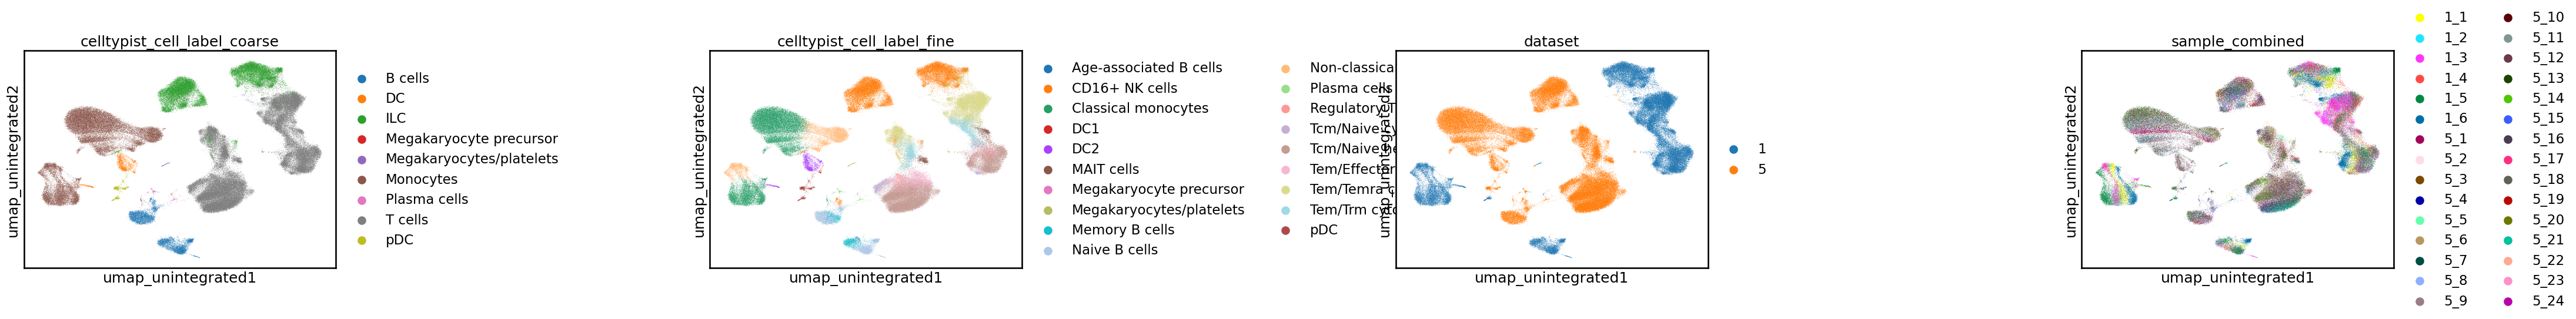

In [16]:
# plot the UMAP (pre integration) coloured by cell type and batch

# adata.uns["dataset" + "_colors"] = [
#     "#1b9e77",
#     "#7570b3", 
# ]  # Set custom colours for batches (add two more when using all datasets)

sc.pl.embedding(adata, basis = "umap_unintegrated", color=["celltypist_cell_label_coarse", "celltypist_cell_label_fine", "dataset", "sample_combined"], wspace=1)

In [17]:
# check on HVG selection

adata.var

,highly_variable,means,dispersions,dispersions_norm,highly_variable_nbatches,highly_variable_intersection
A1BG,False,0.085412,0.674983,0.146029,0,False
A1BG-AS1,False,0.014964,0.686349,-0.693462,0,False
A2M,True,0.046053,0.761224,2.244950,1,False
A2M-AS1,True,0.031452,0.775649,2.652856,2,True
A2ML1,False,0.000128,0.355859,0.128619,0,False
...,...,...,...,...,...,...
ZXDC,False,0.047522,0.673542,-0.628140,0,False
ZYG11A,False,0.000514,0.710910,0.157608,0,False
ZYG11B,False,0.043920,0.698001,0.272951,0,False
ZYX,False,0.298270,0.613831,0.020576,0,False


highly_variable_nbatches
0    19085
1     2270
2      865
Name: count, dtype: int64

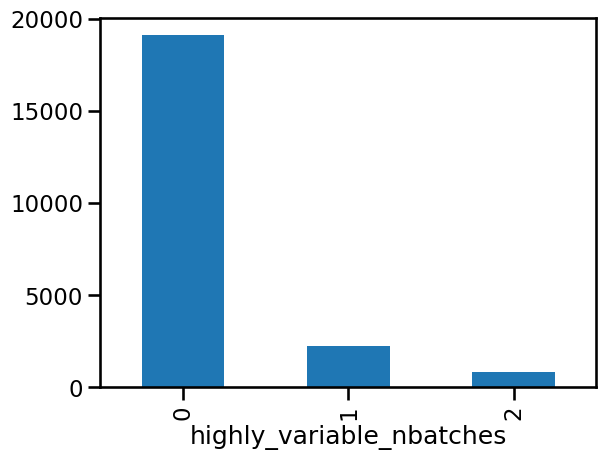

In [ ]:
# check how many batches each gene is variable in

n_batches = adata.var["highly_variable_nbatches"].value_counts()
ax = n_batches.plot(kind="bar")
n_batches

# this is the total number of genes that are highgly variable, of which 2000 are selected (all the ones in 2 and rest from 1)

In [ ]:
# start with simple harmony integration

ho = hm.run_harmony(adata.obsm["X_pca"], adata.obs, "dataset")
adata.obsm["X_pca_harmony"] = ho.Z_corr


print(adata.obsm["X_pca_harmony"].shape)


In [ ]:
# recompute UMAP and neighbours using corrected data

sc.pp.neighbors(adata, use_rep="X_pca_harmony", key_added = "harmony")

sc.tl.umap(adata, neighbors_key="harmony") #writes to X_umap
adata.obsm["X_umap_harmony"] = adata.obsm["X_umap"].copy()

# plot to check for overcorrection
sc.pl.embedding(adata, basis = "umap_harmony", color=["celltypist_cell_label_coarse", "celltypist_cell_label_fine", "dataset", "sample_combined"], wspace=1)

In [ ]:
# create object with just selected genes to use for integration (scVI and scANVI dont work in PCA space, so need subsetted object)

adata_hvg = adata[:, adata.var["highly_variable"]].copy()
adata_hvg


AnnData object with n_obs × n_vars = 132933 × 2000
    obs: 'gsm_id', 'diagnosis', 'age', 'gender', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet', 'leiden_res0_25', 'leiden_res0_5', 'leiden_res1', 'leiden_res2', 'manual_celltype_annotation_0_25', 'celltypist_cell_label_coarse', 'celltypist_conf_score_coarse', 'celltypist_cell_label_fine', 'celltypist_conf_score_fine', 'orig.ident', 'simpl_ID', 'soup_ID_simpl', 'Donor', 'nCount_RNA', 'nFeature_RNA', 'nCount_HTO', 'nFeature_HTO', 'nCount_SCT', 'nFeature_SCT', 'percent.mt', 'predicted.celltype.l1', 'predicted.celltype.l1.score', 'predicted.celltype.l2', 'predicted.celltype.l2.score', 'scibet', 'final_anno', 'final_broad', 'Simplified_Idents', 'ASG_Score1', 'VDJ_barcode', 'CTgene', 'CTnt', 'CTaa', 'CTstrict', 'Frequency', 'cloneT

In [ ]:
# # start with simple harmony integration (trying to see if its different with feature selection)

# adata_harmony = adata_hvg.copy()

# ho = hm.run_harmony(adata_harmony.obsm["X_pca"], adata_harmony.obs, "dataset")
# adata_harmony.obsm["X_pca_harmony"] = ho.Z_corr


# print(adata_harmony.obsm["X_pca_harmony"].shape)


2026-04-23 10:48:16,128 - harmonypy - INFO - Running Harmony (PyTorch on cpu)
2026-04-23 10:48:16,128 - harmonypy - INFO -   Parameters:
2026-04-23 10:48:16,128 - harmonypy - INFO -     max_iter_harmony: 10
2026-04-23 10:48:16,128 - harmonypy - INFO -     max_iter_kmeans: 20
2026-04-23 10:48:16,129 - harmonypy - INFO -     epsilon_cluster: 1e-05
2026-04-23 10:48:16,129 - harmonypy - INFO -     epsilon_harmony: 0.0001
2026-04-23 10:48:16,129 - harmonypy - INFO -     nclust: 100
2026-04-23 10:48:16,129 - harmonypy - INFO -     block_size: 0.05
2026-04-23 10:48:16,130 - harmonypy - INFO -     lamb: [1. 1.]
2026-04-23 10:48:16,130 - harmonypy - INFO -     theta: [2. 2.]
2026-04-23 10:48:16,130 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-04-23 10:48:16,131 - harmonypy - INFO -     verbose: True
2026-04-23 10:48:16,131 - harmonypy - INFO -     random_state: 0
2026-04-23 10:48:16,131 - harmonypy - INFO -   Data: 50 PCs × 132933 cells
2026-04-23 10:48:16,131 - harmonypy - INF

(132933, 50)


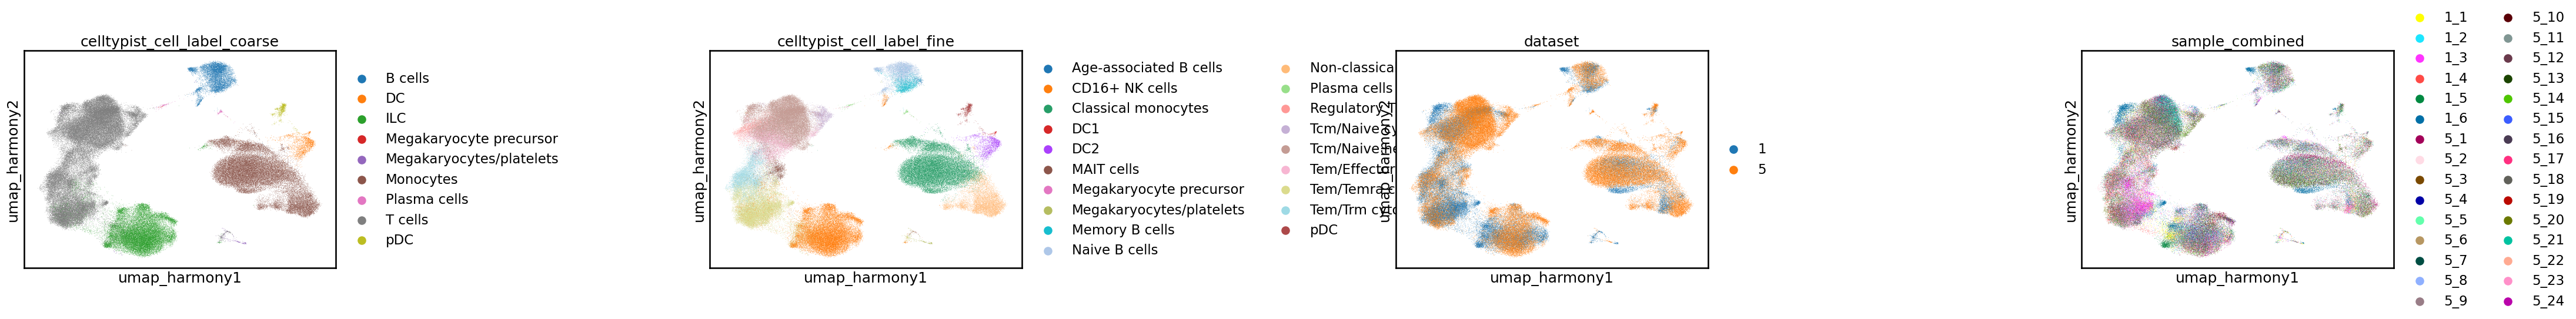

In [ ]:
# # recompute UMAP and neighbours using corrected data

# sc.pp.neighbors(adata_harmony, use_rep="X_pca_harmony", key_added = "harmony")

# sc.tl.umap(adata_harmony, neighbors_key="harmony") #writes to X_umap
# adata_harmony.obsm["X_umap_harmony"] = adata_harmony.obsm["X_umap"].copy()

# # plot to check for overcorrection
# sc.pl.embedding(adata_harmony, basis = "umap_harmony", color=["celltypist_cell_label_coarse", "celltypist_cell_label_fine", "dataset", "sample_combined"], wspace=1)

In [22]:
adata_scvi = adata_hvg.copy()


In [23]:
scvi.model.SCVI.setup_anndata(adata_scvi, layer="counts", batch_key="dataset")
adata_scvi

/rds/general/user/ztb25/home/miniforge3/envs/integrate/lib/python3.11/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.layers[counts] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


AnnData object with n_obs × n_vars = 132933 × 2000
    obs: 'gsm_id', 'diagnosis', 'age', 'gender', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet', 'leiden_res0_25', 'leiden_res0_5', 'leiden_res1', 'leiden_res2', 'manual_celltype_annotation_0_25', 'celltypist_cell_label_coarse', 'celltypist_conf_score_coarse', 'celltypist_cell_label_fine', 'celltypist_conf_score_fine', 'orig.ident', 'simpl_ID', 'soup_ID_simpl', 'Donor', 'nCount_RNA', 'nFeature_RNA', 'nCount_HTO', 'nFeature_HTO', 'nCount_SCT', 'nFeature_SCT', 'percent.mt', 'predicted.celltype.l1', 'predicted.celltype.l1.score', 'predicted.celltype.l2', 'predicted.celltype.l2.score', 'scibet', 'final_anno', 'final_broad', 'Simplified_Idents', 'ASG_Score1', 'VDJ_barcode', 'CTgene', 'CTnt', 'CTaa', 'CTstrict', 'Frequency', 'cloneT

In [24]:
model_scvi = scvi.model.SCVI(adata_scvi)
model_scvi

SCVI model with the following parameters: 
n_hidden: 128, n_latent: 10, n_layers: 1, dropout_rate: 0.1, dispersion: gene, gene_likelihood: zinb, 
latent_distribution: normal.
Training status: Not Trained
Model's adata is minified?: False

In [25]:
# model_scvi.view_anndata_setup()
# come back and fix dependency issue, not necessary for now as this is just to view

In [26]:
max_epochs_scvi = np.min([round((20000 / adata.n_obs) * 400), 400])
print(max_epochs_scvi)

60


In [27]:
model_scvi.train()


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/rds/general/user/ztb25/home/miniforge3/envs/integrate/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.


Epoch 1/60:   0%|          | 0/60 [00:00<?, ?it/s]

/rds/general/user/ztb25/home/miniforge3/envs/integrate/lib/python3.11/site-packages/scvi/module/_vae.py:573: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs[MODULE_KEYS.PX_KEY].log_prob(x).sum(-1)
/rds/general/user/ztb25/home/miniforge3/envs/integrate/lib/python3.11/site-packages/scvi/module/_vae.py:573: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs[MODULE_KEYS.PX_KEY].log_prob(x).sum(-1)


Epoch 5/60:   7%|▋         | 4/60 [02:42<37:31, 40.20s/it, v_num=1, train_loss=465]

/rds/general/user/ztb25/home/miniforge3/envs/integrate/lib/python3.11/site-packages/scvi/module/_vae.py:573: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs[MODULE_KEYS.PX_KEY].log_prob(x).sum(-1)
/rds/general/user/ztb25/home/miniforge3/envs/integrate/lib/python3.11/site-packages/scvi/module/_vae.py:573: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs[MODULE_KEYS.PX_KEY].log_prob(x).sum(-1)


...

Epoch 60/60:  98%|█████████▊| 59/60 [39:12<00:40, 40.03s/it, v_num=1, train_loss=458]

/rds/general/user/ztb25/home/miniforge3/envs/integrate/lib/python3.11/site-packages/scvi/module/_vae.py:573: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs[MODULE_KEYS.PX_KEY].log_prob(x).sum(-1)
/rds/general/user/ztb25/home/miniforge3/envs/integrate/lib/python3.11/site-packages/scvi/module/_vae.py:573: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs[MODULE_KEYS.PX_KEY].log_prob(x).sum(-1)


Epoch 60/60: 100%|██████████| 60/60 [39:51<00:00, 39.76s/it, v_num=1, train_loss=458]

`Trainer.fit` stopped: `max_epochs=60` reached.


Epoch 60/60: 100%|██████████| 60/60 [39:51<00:00, 39.86s/it, v_num=1, train_loss=458]


In [28]:
# extract trained embedding (similar to how PCA dimensions are used)
adata_scvi.obsm["X_scVI"] = model_scvi.get_latent_representation()


In [29]:
# compute scVI batch-corrected neighbors and UMAP
sc.pp.neighbors(adata_scvi, use_rep="X_scVI", key_added = "scVI")

sc.tl.umap(adata_scvi, neighbors_key="scVI")
adata_scvi.obsm["X_umap_scVI"] = adata.obsm["X_umap"].copy() #if HVG also needed for other methods, rename adata_scvi to just adata_hvg
adata_scvi

AnnData object with n_obs × n_vars = 132933 × 2000
    obs: 'gsm_id', 'diagnosis', 'age', 'gender', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet', 'leiden_res0_25', 'leiden_res0_5', 'leiden_res1', 'leiden_res2', 'manual_celltype_annotation_0_25', 'celltypist_cell_label_coarse', 'celltypist_conf_score_coarse', 'celltypist_cell_label_fine', 'celltypist_conf_score_fine', 'orig.ident', 'simpl_ID', 'soup_ID_simpl', 'Donor', 'nCount_RNA', 'nFeature_RNA', 'nCount_HTO', 'nFeature_HTO', 'nCount_SCT', 'nFeature_SCT', 'percent.mt', 'predicted.celltype.l1', 'predicted.celltype.l1.score', 'predicted.celltype.l2', 'predicted.celltype.l2.score', 'scibet', 'final_anno', 'final_broad', 'Simplified_Idents', 'ASG_Score1', 'VDJ_barcode', 'CTgene', 'CTnt', 'CTaa', 'CTstrict', 'Frequency', 'cloneT

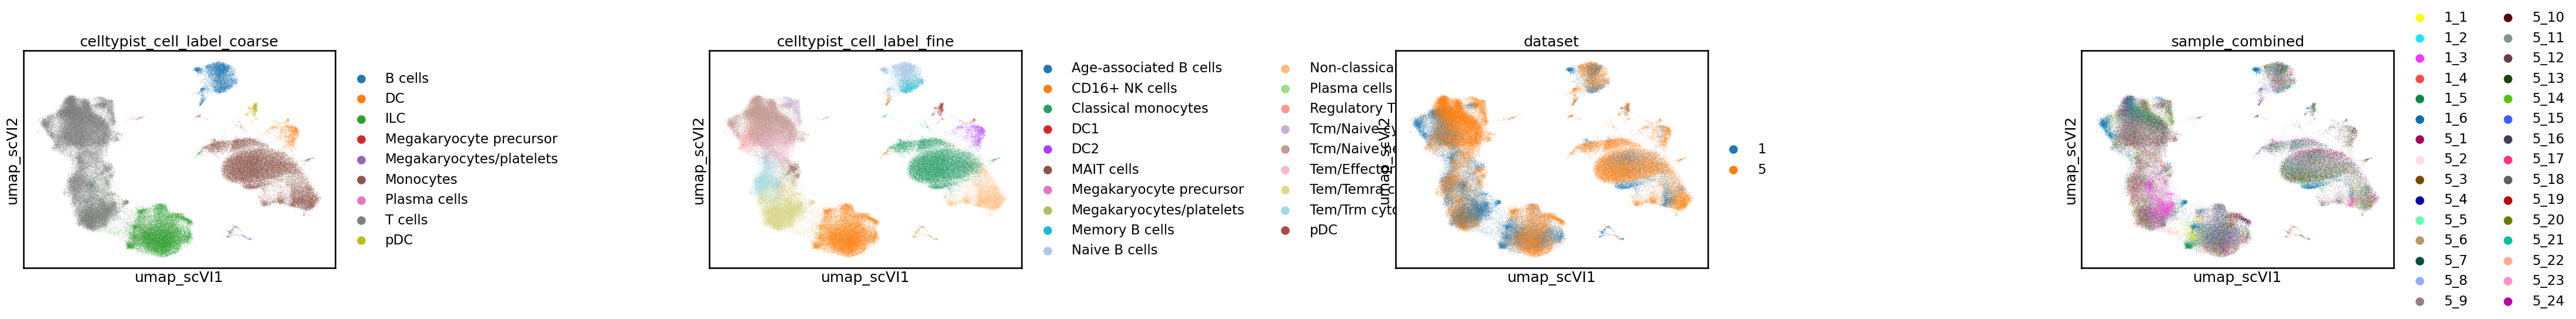

In [30]:
# plot UMAP
sc.pl.embedding(adata_scvi, basis="umap_scVI", color=["celltypist_cell_label_coarse", "celltypist_cell_label_fine", "dataset", "sample_combined"], wspace=1)

In [31]:
# integration method 3: scANVI

model_scanvi = scvi.model.SCANVI.from_scvi_model(
    model_scvi, labels_key="celltypist_cell_label_coarse", unlabeled_category="unlabelled" # first with broad cell type annos
)
print(model_scanvi)
# model_scanvi.view_anndata_setup()

/rds/general/user/ztb25/home/miniforge3/envs/integrate/lib/python3.11/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.layers[counts] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


ScanVI Model with the following params: 
unlabeled_category: unlabelled, n_hidden: 128, n_latent: 10, n_layers: 1, dropout_rate: 0.1, dispersion: gene, 
gene_likelihood: zinb
Training status: Not Trained
Model's adata is minified?: False

In [32]:
# heuristic for deciding number of epochs for scANVI training

max_epochs_scanvi = int(np.min([10, np.max([2, round(max_epochs_scvi / 3.0)])]))
model_scanvi.train(max_epochs=max_epochs_scanvi)

INFO     Training for 10 epochs.                                                                                   


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/rds/general/user/ztb25/home/miniforge3/envs/integrate/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.


Epoch 1/10:   0%|          | 0/10 [00:00<?, ?it/s]

/rds/general/user/ztb25/home/miniforge3/envs/integrate/lib/python3.11/site-packages/scvi/module/_scanvae.py:223: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -px.log_prob(x).sum(-1)


Epoch 2/10:  10%|█         | 1/10 [00:56<08:30, 56.77s/it, v_num=1, train_loss=465]

...

Epoch 10/10:  90%|█████████ | 9/10 [08:11<00:55, 55.19s/it, v_num=1, train_loss=453]

/rds/general/user/ztb25/home/miniforge3/envs/integrate/lib/python3.11/site-packages/scvi/module/_scanvae.py:223: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -px.log_prob(x).sum(-1)


Epoch 10/10: 100%|██████████| 10/10 [09:03<00:00, 54.19s/it, v_num=1, train_loss=453]

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 10/10: 100%|██████████| 10/10 [09:03<00:00, 54.39s/it, v_num=1, train_loss=453]


In [33]:
adata_scanvi = adata_scvi.copy() # check if i want to be making new adata objects for each methods or just use keys and reps within the same adata object
adata_scanvi.obsm["X_scANVI"] = model_scanvi.get_latent_representation()
sc.pp.neighbors(adata_scanvi, use_rep="X_scANVI")
sc.tl.umap(adata_scanvi)
sc.pl.embedding(adata_scanvi,  color=["celltypist_cell_label_coarse", "celltypist_cell_label_fine", "dataset", "sample_combined"], wspace=1)


: 

: 

: 